# 4. 청구입금정보 (청구/입금 정보) EDA

카테고리 4 = **어떻게 결제하나 / 청구·포인트·혜택**. 46개 컬럼. (파일명은 `청구정보`)
라벨 `Segment`는 회원정보(카테고리 1)에서 조인.

**사전 발견**: Segment는 이용/가치 등급(A상위~E하위)의 **순서형**. 03 승인매출에서 상환 행동(정상입금원금)이 강했고, 여기 `청구금액`·포인트 적립도 소비와 연동되므로 순서형 신호가 강할 것으로 예상.

**컬럼 구조**: 청구금액(B0/R3M/R6M), 포인트·마일(적립/이용/잔여, 기간별), 할인·혜택수혜금액, 결제·청구 방식(결제일/청구서 수령/발송), 상환개월수·선결제건수·연체건수.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family']='Malgun Gothic'; plt.rcParams['axes.unicode_minus']=False
pd.set_option('display.max_columns',200); pd.set_option('display.width',220)
import glob, os
ROOT = os.path.abspath(os.path.join(os.getcwd(),'..')) if os.path.basename(os.getcwd())=='eda' else os.getcwd()
MONTH='201812'; SEG_ORDER=['A','B','C','D','E']
SEG_COLORS={'A':'#d1495b','B':'#edae49','C':'#66a182','D':'#2e4057','E':'#8d96a3'}
print('ROOT =', ROOT)

ROOT = C:\Users\82109\Desktop\DACON


## 1. 데이터 로드 (201812 청구입금) + 라벨 조인

In [2]:
f4 = glob.glob(os.path.join(ROOT,'train','4.*',f'{MONTH}_*.parquet'))[0]
df = pd.read_parquet(f4)
lbl = pd.read_parquet(glob.glob(os.path.join(ROOT,'train','1.*',f'{MONTH}_*.parquet'))[0], columns=['ID','Segment'])
df = df.merge(lbl, on='ID', how='left')
assert df['Segment'].notna().all()
print('shape:', df.shape); df.head(3)

shape: (400000, 47)


,기준년월,ID,대표결제일,대표결제방법코드,대표청구지고객주소구분코드,대표청구서수령지구분코드,청구서수령방법,청구서발송여부_B0,청구서발송여부_R3M,청구서발송여부_R6M,청구금액_B0,청구금액_R3M,청구금액_R6M,포인트_마일리지_건별_B0M,포인트_마일리지_건별_R3M,포인트_포인트_건별_B0M,포인트_포인트_건별_R3M,포인트_마일리지_월적립_B0M,포인트_마일리지_월적립_R3M,포인트_포인트_월적립_B0M,포인트_포인트_월적립_R3M,포인트_적립포인트_R12M,포인트_적립포인트_R3M,포인트_이용포인트_R12M,포인트_이용포인트_R3M,포인트_잔여포인트_B0M,마일_적립포인트_R12M,마일_적립포인트_R3M,마일_이용포인트_R12M,마일_이용포인트_R3M,마일_잔여포인트_B0M,할인건수_R3M,할인금액_R3M,할인건수_B0M,할인금액_B0M,할인금액_청구서_R3M,할인금액_청구서_B0M,상환개월수_결제일_R6M,상환개월수_결제일_R3M,선결제건수_R6M,선결제건수_R3M,연체건수_R6M,연체건수_R3M,혜택수혜금액_R3M,포인트_마일리지_환산_B0M,혜택수혜금액,Segment
0,201812,TRAIN_000000,27,자동이체,미확인,당사페이앱+이메일,문자메세지,1,1,1,13976,42163,85879,0,0,1201,3641,0,0,0,0,3412,1514,2274,916,0,0,0,0,0,0,1회 이상,0,1회 이상,0,0,0,6,3,0,0,0,0,0,0,0,D
1,201812,TRAIN_000001,13,자동이체,주거지,우편,우편,1,1,1,2442,8539,21012,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1회 이상,0,1회 이상,0,490,163,6,3,0,0,0,0,0,0,0,E
2,201812,TRAIN_000002,12,자동이체,미확인,이메일,이메일,1,1,1,31404,84250,156628,0,0,2120,6643,0,0,0,0,10311,4730,3859,2477,0,0,0,0,0,0,1회 이상,0,1회 이상,0,0,0,6,3,0,0,0,0,109,0,13,C


## 2. 컬럼 개요 — dtype / 결측 / 카디널리티

In [3]:
meta = pd.DataFrame({'dtype':df.dtypes.astype(str),'n_missing':df.isna().sum(),
    'missing_%':(df.isna().mean()*100).round(2),'nunique':df.nunique(dropna=True)})
meta.sort_values(['nunique','missing_%'])

,dtype,n_missing,missing_%,nunique
기준년월,int64,0,0.0,1
대표결제방법코드,str,0,0.0,1
청구서발송여부_B0,int64,0,0.0,2
청구서발송여부_R3M,int64,0,0.0,2
청구서발송여부_R6M,int64,0,0.0,2
할인건수_B0M,str,0,0.0,2
대표청구지고객주소구분코드,str,0,0.0,3
상환개월수_결제일_R3M,int64,0,0.0,4
할인건수_R3M,str,0,0.0,5
선결제건수_R3M,int64,0,0.0,5


### 2-1. 버릴 후보 — 상수 & 고결측

In [4]:
const_cols = meta.index[meta['nunique']<=1].tolist()
high_missing = meta.index[meta['missing_%']>=40].tolist()
print(f'상수 컬럼 {len(const_cols)}개:', const_cols)
print(f'고결측(>=40%) {len(high_missing)}개:', high_missing)

상수 컬럼 2개: ['기준년월', '대표결제방법코드']
고결측(>=40%) 0개: []


## 3. 세그먼트별 청구금액 & 포인트 (핵심 지표)

청구금액은 소비와 직결, 포인트 적립도 소비 연동 → 순서형 검증.

In [5]:
rep = [c for c in ['청구금액_B0','청구금액_R3M','청구금액_R6M',
                    '포인트_적립포인트_R12M','포인트_이용포인트_R12M','포인트_잔여포인트_B0M',
                    '혜택수혜금액_R3M','할인금액_R3M'] if c in df.columns]
print('세그먼트별 중앙값:')
print(df.groupby('Segment')[rep].median().reindex(SEG_ORDER).T.to_string())

세그먼트별 중앙값:
Segment                A         B         C        D       E
청구금액_B0          44690.5   41744.5   17345.0   8528.0  1373.0
청구금액_R3M        136765.0  139796.5   54644.0  26935.0  4461.0
청구금액_R6M        292211.5  296919.5  111646.0  55741.0  9607.5
포인트_적립포인트_R12M       0.0       0.0       0.0      0.0     0.0
포인트_이용포인트_R12M       0.0    4015.5     640.0      0.0     0.0
포인트_잔여포인트_B0M        0.0       0.0       0.0      0.0     0.0
혜택수혜금액_R3M         827.5     837.0     165.0    146.0     0.0
할인금액_R3M             0.0       0.0       0.0      0.0     0.0


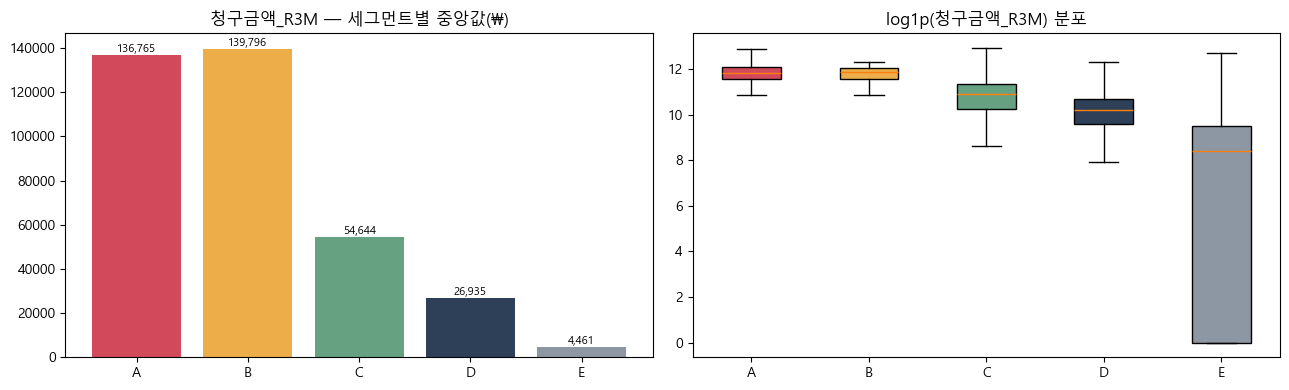

In [6]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
m1 = df.groupby('Segment')['청구금액_R3M'].median().reindex(SEG_ORDER)
ax[0].bar(SEG_ORDER, m1.values, color=[SEG_COLORS[s] for s in SEG_ORDER])
ax[0].set_title('청구금액_R3M — 세그먼트별 중앙값(₩)')
for i,v in enumerate(m1.values): ax[0].text(i,v,f'{v:,.0f}',ha='center',va='bottom',fontsize=8)
data=[np.log1p(df.loc[df['Segment']==s,'청구금액_R3M'].clip(lower=0)) for s in SEG_ORDER]
bp=ax[1].boxplot(data, labels=SEG_ORDER, showfliers=False, patch_artist=True)
for p,s in zip(bp['boxes'],SEG_ORDER): p.set_facecolor(SEG_COLORS[s])
ax[1].set_title('log1p(청구금액_R3M) 분포'); plt.tight_layout(); plt.show()

## 4. Segment를 잘 가르는 수치형 피처 랭킹

In [7]:
drop=set(const_cols)|{'기준년월'}
num_cols=[c for c in df.columns if c not in drop and c not in ('ID','Segment') and pd.api.types.is_numeric_dtype(df[c])]
print('수치형 분석 대상:', len(num_cols))
med=df.groupby('Segment')[num_cols].median().reindex(SEG_ORDER).T
iqr=(df[num_cols].quantile(0.75)-df[num_cols].quantile(0.25)).replace(0,np.nan)
sep=((med.max(axis=1)-med.min(axis=1))/(iqr+1e-9)).sort_values(ascending=False)
def monotonic(row):
    v=row.values.astype(float); return np.all(np.diff(v)<=0) or np.all(np.diff(v)>=0)
med_sorted=med.loc[sep.index]; med_sorted.insert(0,'sep_score',sep.round(2))
med_sorted['monotonic']=med.loc[sep.index].apply(monotonic,axis=1)
print('분리도 상위 20:')
med_sorted.head(20)

수치형 분석 대상: 38


분리도 상위 20:


Segment,sep_score,A,B,C,D,E,monotonic
청구금액_R6M,7.32,292211.5,296919.5,111646.0,55741.0,9607.5,False
청구금액_R3M,7.10,136765.0,139796.5,54644.0,26935.0,4461.0,False
청구금액_B0,6.96,44690.5,41744.5,17345.0,8528.0,1373.0,True
혜택수혜금액_R3M,5.58,827.5,837.0,165.0,146.0,0.0,False
혜택수혜금액,5.54,277.0,274.0,54.0,48.0,0.0,True
포인트_이용포인트_R12M,1.88,0.0,4015.5,640.0,0.0,0.0,False
대표결제일,0.62,23.0,15.0,20.0,20.0,20.0,False
상환개월수_결제일_R6M,0.60,6.0,3.0,6.0,6.0,5.0,False
상환개월수_결제일_R3M,0.50,3.0,1.5,3.0,3.0,3.0,False
할인금액_R3M,0.00,0.0,0.0,0.0,0.0,0.0,True


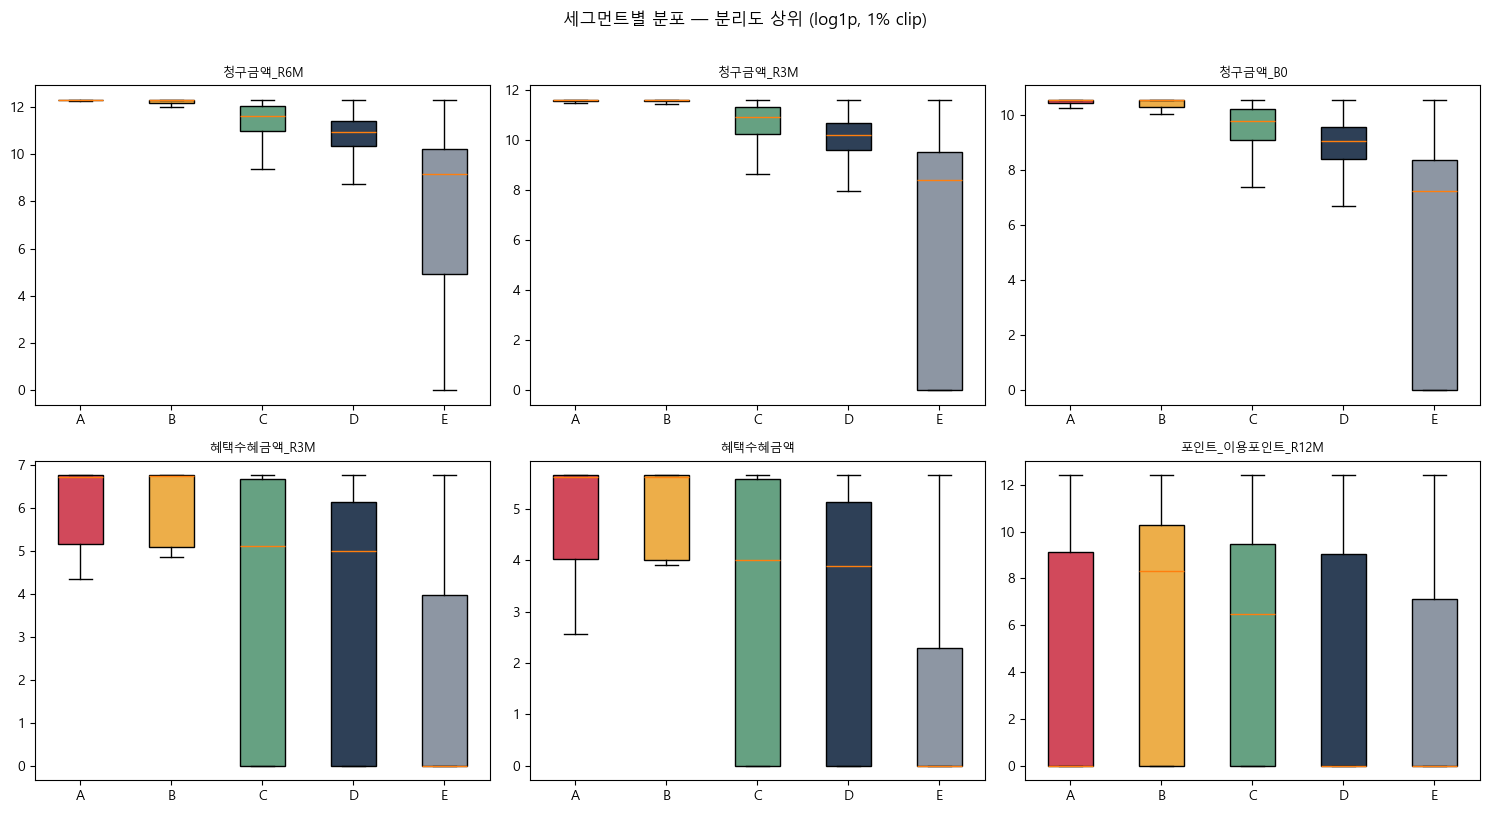

In [8]:
top_feats=sep.index[:6].tolist()
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,feat in zip(axes.ravel(),top_feats):
    q99=df[feat].quantile(0.99)
    data=[np.log1p(df.loc[df['Segment']==s,feat].clip(lower=0,upper=q99)) for s in SEG_ORDER]
    bp=ax.boxplot(data,labels=SEG_ORDER,showfliers=False,patch_artist=True)
    for p,s in zip(bp['boxes'],SEG_ORDER): p.set_facecolor(SEG_COLORS[s])
    ax.set_title(feat,fontsize=9)
plt.suptitle('세그먼트별 분포 — 분리도 상위 (log1p, 1% clip)',y=1.01); plt.tight_layout(); plt.show()

## 5. 결제·청구 방식 (범주형) vs Segment

결제일/청구서 수령방법/할인건수 등 습관성 피처가 세그먼트와 얽히는지.

In [9]:
cat_cols=[c for c in ['대표청구지고객주소구분코드','대표청구서수령지구분코드','청구서수령방법',
                      '할인건수_R3M','할인건수_B0M','청구서발송여부_R6M'] if c in df.columns]
for c in cat_cols:
    ct=pd.crosstab(df[c],df['Segment']).reindex(columns=SEG_ORDER,fill_value=0)
    row_pct=(ct.div(ct.sum(axis=1),axis=0)*100).round(1); out=row_pct.copy(); out['n']=ct.sum(axis=1)
    print(f'\n=== {c} : 값별 세그먼트 구성비(%) ===')
    print(out.sort_values('n',ascending=False).to_string())


=== 대표청구지고객주소구분코드 : 값별 세그먼트 구성비(%) ===
Segment          A    B    C     D     E       n
대표청구지고객주소구분코드                                   
미확인            0.0  0.0  6.5  17.1  76.4  187244
주거지            0.0  0.0  4.0  12.2  83.8  171471
회사             0.1  0.0  5.2  13.0  81.7   41285

=== 대표청구서수령지구분코드 : 값별 세그먼트 구성비(%) ===
Segment         A    B    C     D     E       n
대표청구서수령지구분코드                                   
우편            0.0  0.0  4.3  12.4  83.3  213287
이메일           0.1  0.0  7.1  17.4  75.5  133577
당사페이앱+이메일     0.0  0.0  4.7  15.7  79.5   41973
미수신           0.0  0.0  5.1  15.4  79.5    6344
K톡명세서+이메일     0.0  0.0  7.9  22.1  69.9    4812
당사멤버십+이메일     0.0  0.0  0.0  28.6  71.4       7

=== 청구서수령방법 : 값별 세그먼트 구성비(%) ===
Segment    A    B    C     D     E       n
청구서수령방법                                   
우편       0.0  0.0  4.3  12.4  83.3  213287
이메일      0.1  0.0  7.1  17.4  75.5  133577
문자메세지    0.0  0.0  4.7  15.7  79.5   41973
미수령      0.0  0.0  5.1  15.4  79.5    6344



=== 할인건수_R3M : 값별 세그먼트 구성비(%) ===
Segment     A    B      C     D     E       n
할인건수_R3M                                     
1회 이상     0.0  0.0    4.1  11.6  84.2  351819
10회 이상    0.1  0.0   12.5  33.7  53.7   37590
20회 이상    0.0  0.0   17.1  42.0  40.9    9189
30회 이상    0.0  0.0   27.5  55.6  16.9    1401
40회 이상    0.0  0.0  100.0   0.0   0.0       1

=== 할인건수_B0M : 값별 세그먼트 구성비(%) ===
Segment     A    B     C     D     E       n
할인건수_B0M                                    
1회 이상     0.0  0.0   5.2  14.4  80.4  398028
10회 이상    0.0  0.0  27.1  53.8  19.2    1972

=== 청구서발송여부_R6M : 값별 세그먼트 구성비(%) ===
Segment        A    B    C     D     E       n
청구서발송여부_R6M                                   
1            0.0  0.0  6.4  17.2  76.3  327186
0            0.0  0.0  0.6   2.5  96.9   72814


## 6. 상환·연체 행동 & 소수클래스 A / B

In [10]:
# 상환/연체/선결제 세그먼트별 (건전성 지표)
beh=[c for c in ['상환개월수_결제일_R6M','선결제건수_R6M','연체건수_R6M','연체건수_R3M'] if c in df.columns]
print('=== 상환·연체 행동 세그먼트별 중앙값 ===')
print(df.groupby('Segment')[beh].median().reindex(SEG_ORDER).T.to_string())
print('\n=== 연체건수_R6M 세그먼트별 평균(희귀 이벤트라 mean) ===')
print(df.groupby('Segment')['연체건수_R6M'].mean().reindex(SEG_ORDER).round(3).to_string())

=== 상환·연체 행동 세그먼트별 중앙값 ===
Segment          A    B    C    D    E
상환개월수_결제일_R6M  6.0  3.0  6.0  6.0  5.0
선결제건수_R6M      0.0  1.0  0.0  0.0  0.0
연체건수_R6M       0.0  0.0  0.0  0.0  0.0
연체건수_R3M       0.0  0.0  0.0  0.0  0.0

=== 연체건수_R6M 세그먼트별 평균(희귀 이벤트라 mean) ===


Segment
A    0.383
B    0.708
C    0.555
D    0.558
E    0.369


In [11]:
glob_med=df[num_cols].median(); a_med=df[df['Segment']=='A'][num_cols].median(); b_med=df[df['Segment']=='B'][num_cols].median()
cmp=pd.DataFrame({'A_median':a_med,'B_median':b_med,'ALL_median':glob_med})
cmp['A_vs_B_absdiff']=(a_med-b_med).abs()
print('=== A vs B 차이 큰 피처 (분리 후보) ===')
print(cmp.sort_values('A_vs_B_absdiff',ascending=False).head(15).to_string())

=== A vs B 차이 큰 피처 (분리 후보) ===
                 A_median  B_median  ALL_median  A_vs_B_absdiff
청구금액_R6M         292211.5  296919.5     15730.0          4708.0
포인트_이용포인트_R12M        0.0    4015.5         0.0          4015.5
포인트_이용포인트_R3M         0.0    3304.5         0.0          3304.5
청구금액_R3M         136765.0  139796.5      7448.0          3031.5
청구금액_B0           44690.5   41744.5      2337.0          2946.0
마일_적립포인트_R3M       2528.0     959.0         0.0          1569.0
포인트_적립포인트_R3M         0.0     554.5         0.0           554.5
포인트_마일리지_환산_B0M     167.0      31.0         0.0           136.0
혜택수혜금액_R3M          827.5     837.0         0.0             9.5
대표결제일                23.0      15.0        20.0             8.0
상환개월수_결제일_R6M         6.0       3.0         6.0             3.0
혜택수혜금액              277.0     274.0         0.0             3.0
상환개월수_결제일_R3M         3.0       1.5         3.0             1.5
선결제건수_R3M             0.0       1.0         0.0             1.0
선결제건수_R6M

## 7. 요약 & 발견

### 청구금액 = 최상위 분리 피처 (소비 순서형 재확인)
`청구금액_R6M/R3M/B0`가 분리도 상위권(sep 7+). 중앙값 `청구금액_R6M`: **A 292k · B 297k · C 112k · D 56k · E 9.6k**. C→E는 완전 단조. 청구금액은 소비의 또 다른 강한 프록시 → 피처로 매우 유용.

### ★ A vs B: 청구금액은 사실상 동률(B가 미세하게 A 초과)이지만, **B의 결제·리워드 행동이 A와 다름**
- **청구금액 R6M/R3M에서 B ≥ A** (B 297k vs A 292k) → 둘 다 최상위 소비. 규모론 A/B 못 가름.
- 그런데 **B는 포인트를 쓴다**: `포인트_이용포인트_R12M` 중앙값 **B 4,015 vs A 0**. `선결제건수` B 1 vs A 0. `상환개월수_결제일` B 3 vs A 6(빠른 상환/적은 할부). `대표결제일` B 15일 vs A 23일.
- 반대로 `마일_적립포인트_R3M`은 A 2,528 vs B 959로 A가 큼.
→ **A = 마일 적립형 고소비, B = 포인트 소진·선결제·단기상환형 고소비.** 신용정보(고금리·카드론無)에 이어 **A/B를 가르는 두 번째 축.**

### ★ B의 리스크 신호 — 연체
`연체건수_R6M` 평균이 **B 0.708로 최고**(A 0.383, E 0.369). 신용정보의 B 고금리와 일관 → **B ≈ 고소비지만 위험/리볼빙 성향** 프로필로 수렴.

### 범주형 신호
- `할인건수`가 많을수록 **C·D(중상위)** 집중(30회↑ 구간 C+D 83%) → 헤비 할인 이용자는 중간 등급.
- `청구서발송여부_R6M=0`(청구서 미발송=사실상 미이용)는 **E 96.9%** → 휴면 E 식별 플래그.
- 청구서 수령방법(이메일/K톡 등 디지털)일수록 C/D 비중↑, 우편일수록 E↑(고령·저이용).

### 전처리 메모
- 상수 2개(`기준년월`,`대표결제방법코드`='자동이체' 전원) 제거. 결측 없음.
- 포인트·할인금액 상당수 중앙값 0(소수만 값 보유) → 0-inflated. 보유여부 플래그 + 값 분리 인코딩 고려.

**다음 카테고리**: 5.잔액정보 (부채/리볼빙 잔액 — B 리볼빙 가설 추가 검증 가능).